# npE Plotting and Analysis Tools

In [2]:
project_path = '~/projects/npe'

In [3]:
import warnings
warnings.filterwarnings('ignore', message='You are using `torch.load` with `weights_only=False`*', category=FutureWarning)

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import lal

npe_dir = os.path.abspath(os.path.expanduser(os.path.join(project_path, 'npe')))
if npe_dir not in sys.path:
    sys.path.append(npe_dir)

from waveform_analysis import VAE

MSUN_KM = lal.MSUN_SI * lal.G_SI / lal.C_SI ** 2 / 1e3
MSUN_S  = MSUN_KM / lal.C_SI * 1e3

/tmp/ipykernel_1563542/4055859350.py:9: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [ ]:
#import locale

#_ = locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

In [4]:
from workflow import initialize

# Import PyTorch network
def import_network(network_path, base_path=project_path, network_type='BBH'):

    network_fullpath = os.path.expanduser(os.path.join(base_path, network_path))

    device = torch.device('cpu')
    model_kwargs = dict(depth=4, width=512, data_dim=640, grid_dim=2, freeze_shape=True)
    optimizer_kwargs = dict(lr=1e-4, weight_decay=1e-4)
    scheduler_kwargs = dict(gamma=0.9)
    
    model_type = VAE
    optimizer_type = torch.optim.AdamW
    scheduler_type = torch.optim.lr_scheduler.ExponentialLR

    model, optimizer, scheduler = initialize(
                                    model_type, optimizer_type, scheduler_type,
                                    model_kwargs=model_kwargs,
                                    optimizer_kwargs=optimizer_kwargs,
                                    scheduler_kwargs=scheduler_kwargs, device=device)
    
    state_dict = torch.load(network_fullpath, map_location=device, weights_only=True)

    model = model_type(**model_kwargs).to(device)
    optimizer = optimizer_type(model.parameters(), **optimizer_kwargs)
    scheduler = scheduler_type(optimizer, **scheduler_kwargs)

    model.load_state_dict(state_dict['model'])
    if optimizer is not None: optimizer.load_state_dict(state_dict['optimizer'])
    if scheduler is not None: scheduler.load_state_dict(state_dict['scheduler'])

    model.eval()
    model.train(False)

    return model, device, optimizer, scheduler

## Plot Dephasing

In [5]:
def plot_dephasing(network_path, base_path=project_path, network_type='BBH', sample_zmags=False, show_plot=True, title='',
                   z_ang_min=0., z_ang_max=2*np.pi):
    if network_type not in ['BBH', 'BNS']:
        print('Error: Unsupported network_type. Defaulting to network_type=\'BBH\'')
        network_type = 'BBH'
    # Import specified network
    #model, device = import_network(network_path, base_path)
    model, device, _, _ = import_network(network_path, base_path)

    # Get dephasing values from shape function
    if network_type == 'BNS':
        f_min = 0.00004
        f_max = 0.018
        f_num = 640

        m_min = 0.6
        m_max = 3.0
    elif network_type == 'BBH':
        f_min = 0.0004
        f_max = 0.018
        f_num = 640

        m_min = 5.0
        m_max = 30.0
    else:
        print('Error')
        return False

    #z_mag = np.linspace(0, 1, 100)
    #z_mag = 0.5
    z_ang_arr = np.linspace(z_ang_min, z_ang_max, 360)

    if sample_zmags:
        z1_arr = np.array([np.random.uniform(0,1) * np.cos(z_ang) for z_ang in z_ang_arr])
        z2_arr = np.array([np.random.uniform(0,1) * np.sin(z_ang) for z_ang in z_ang_arr])
    else:
        z1_arr = np.array([0.5 * np.cos(z_ang) for z_ang in z_ang_arr])
        z2_arr = np.array([0.5 * np.sin(z_ang) for z_ang in z_ang_arr])

    norm_fac = 1.

    print('z1: ', z1_arr.shape)
    print('z2: ', z2_arr.shape)

    # Loop the below over all sampled z_theta values
    for z1, z2 in zip(z1_arr, z2_arr):
        z_mag = np.sqrt(z1**2 + z2**2)
        ## TODO: Finish adapting all of this
        f_min_geom = f_min*(2*m_min*MSUN_S)
        f_max_geom = f_max*(2*m_max*MSUN_S)
        # TODO: Should we provide unitless or geometric frequencies?
        freqs = np.linspace(f_min, f_max, f_num)
        geom_freqs = np.linspace(f_min_geom, f_max_geom, f_num)
        model_loggeom_freqs = np.linspace(np.log10(f_min_geom), np.log10(f_max_geom), f_num)
        geom_freqs_cutoff = np.exp(model_loggeom_freqs[-1])
        mask_low = geom_freqs <= 0
        mask_high = geom_freqs > geom_freqs_cutoff
        mask_mid = ~(mask_low|mask_high)
        #loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
        loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
        loggeom_freq_range = model_loggeom_freqs[-1] - model_loggeom_freqs[0]
        xin = (loggeom_freqs - model_loggeom_freqs[0]) / loggeom_freq_range
        xin = torch.tensor(xin, dtype=torch.float32, device=device).view(1, -1)

        # TODO: What values of z and cond do we need?
        z = torch.tensor([z1/z_mag, z2/z_mag], dtype=torch.float32, device=device).view(1, -1)
        #cond = self.gw_params_to_vae_labels(mass_1, mass_2, chi_1, chi_2) # returns: [Mc, eta, chi_sym, chi_asym]
        cond = [25, 1, 0, 0]
        cond = torch.tensor(cond, dtype=torch.float32, device=device).view(1, -1)
        #print('z: ', z.shape)
        #print('cond: ', cond.shape)

        Sout, dSout = model.extended_decoder(z, cond, xin)

        #print('Sout: ', Sout.shape)

        xout, dext = Sout.view(-1).cpu().detach().numpy().flatten(), dSout.item()

        #print('xout: ', xout.shape)
        #print('dext: ', dext)
        #print('Sout: ', Sout.shape)

        Smag = np.sqrt(np.sum([xout_val**2 for xout_val in xout]))
        #print('Smag: ', Smag)

        phases_mod = np.zeros_like(geom_freqs)
        phases_mod[mask_mid] = xout[:-1]
        phases_mod[mask_high] = xout[-1] + dext / loggeom_freq_range / np.log(10) * (geom_freqs[mask_high] / geom_freqs_cutoff - 1.)
        phases_mod *= z_mag * norm_fac / Smag

        #print('phases_mod: ', phases_mod.shape)

        if show_plot:
            # Plot dephasing
            x_vals = freqs
            y_vals = phases_mod

            #print(Sout)
            #print(dext)
            #print(xout)
            #print(phases_mod)

            plt.plot(x_vals, y_vals, color='b', alpha=0.7, lw=0.15)

    if show_plot:
        plt.xlabel(r'$\bar{f}$')
        plt.ylabel(r'$\hat{S}(f)$')
        plt.xscale('log')
        #plt.yscale('log')
        plt.grid()
        #plt.legend()
        #plt.xlim(f_min_geom, 1e-7)

        plt.title(title)

        plt.tight_layout
        plt.show()
        
    if show_plot and False:
        # Plot in latent-space plane
        x_vals_2, y_vals_2 = np.zip([z1_arr, z2_arr])
        plt.plot(x_vals_2, y_vals_2)
        plt.xlabel(r'$z_1$')
        plt.ylabel(r'$z_2$')
        plt.tight_layout()
        plt.show()

In [3]:
# Get and plot maximal value for dS/dtheta

def get_dSdtheta(network_path, base_path=project_path, network_type='BBH', sample_zmags=False, show_plot=True, title=''):
    if network_type not in ['BBH', 'BNS']:
        print('Error: Unsupported network_type. Defaulting to network_type=\'BBH\'')
        network_type = 'BBH'
    # Import specified network
    #model, device = import_network(network_path, base_path)
    model, device, _, _ = import_network(network_path, base_path)

    # Get dephasing values from shape function
    if network_type == 'BNS':
        f_min = 0.00004
        f_max = 0.018
        f_num = 640

        m_min = 0.6
        m_max = 3.0
    elif network_type == 'BBH':
        f_min = 0.0004
        f_max = 0.018
        f_num = 640

        m_min = 5.0
        m_max = 30.0
    else:
        print('Error')
        return False

    #z_mag = np.linspace(0, 1, 100)
    #z_mag = 0.5
    z_theta_arr = np.linspace(0, np.pi, 360)

    if sample_zmags:
        z1_arr = np.array([np.random.uniform(0,1) * np.cos(z_theta) for z_theta in z_theta_arr])
        z2_arr = np.array([np.random.uniform(0,1) * np.sin(z_theta) for z_theta in z_theta_arr])
    else:
        z1_arr = np.array([0.5 * np.cos(z_theta) for z_theta in z_theta_arr])
        z2_arr = np.array([0.5 * np.sin(z_theta) for z_theta in z_theta_arr])

    # Loop the below over all sampled z_theta values
    for z1, z2 in zip(z1_arr, z2_arr):
        z_mag = np.sqrt(z1**2 + z2**2)
        ## TODO: Finish adapting all of this
        f_min_geom = f_min*(2*m_min*MSUN_S)
        f_max_geom = f_max*(2*m_max*MSUN_S)
        # TODO: Should we provide unitless or geometric frequencies?
        freqs = np.linspace(f_min, f_max, f_num)
        geom_freqs = np.linspace(f_min_geom, f_max_geom, f_num)
        model_loggeom_freqs = np.linspace(np.log10(f_min_geom), np.log10(f_max_geom), f_num)
        geom_freqs_cutoff = np.exp(model_loggeom_freqs[-1])
        mask_low = geom_freqs <= 0
        mask_high = geom_freqs > geom_freqs_cutoff
        mask_mid = ~(mask_low|mask_high)
        #loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
        loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
        loggeom_freq_range = model_loggeom_freqs[-1] - model_loggeom_freqs[0]
        xin = (loggeom_freqs - model_loggeom_freqs[0]) / loggeom_freq_range
        xin = torch.tensor(xin, dtype=torch.float32, device=device).view(1, -1)

        z = torch.tensor([z1/z_mag, z2/z_mag], dtype=torch.float32, device=device).view(1, -1)
        #cond = self.gw_params_to_vae_labels(mass_1, mass_2, chi_1, chi_2) # returns: [Mc, eta, chi_sym, chi_asym]
        cond = [25, 1, 0, 0]
        cond = torch.tensor(cond, dtype=torch.float32, device=device).view(1, -1)
        #print('z: ', z.shape)
        #print('cond: ', cond.shape)
        norm_fac = 1.

        Sout, dSout = model.extended_decoder(z, cond, xin)
        # TODO: Finish adapting all of this
        xout, dext = Sout.view(-1).cpu().detach().numpy().flatten(), dSout.item()
        Smag = np.sqrt(np.sum([xout_val**2 for xout_val in xout]))

        phases_mod = np.zeros_like(geom_freqs)
        phases_mod[mask_mid] = xout[:-1]
        phases_mod[mask_high] = xout[-1] + dext / loggeom_freq_range / np.log(10) * (geom_freqs[mask_high] / geom_freqs_cutoff - 1.)
        phases_mod *= z_mag * norm_fac / Smag

    if show_plot:
        y_vals = np.gradient(phases_mod)
        plt.plot(z_theta_arr, dext)

### Example plots

In [6]:
# Example network paths
example_network_path = './npe/utils/param_estimation_test/npe_network.pt'   # Example network
BBH_network_path = './network/checkpoints/npe-BH/npe-BH_100-epochs.pt'  # BBH network
BBH_network_path_3 = './network/checkpoints/npe-BH-3/npe-BH_100-epochs.pt'  # BBH network (bad seed ?)
BBH_network_path_3_1 = './network/checkpoints/npe-BH-3-1/npe-BH_100-epochs.pt'  # BBH network 3-1
BBH_network_path_3_2 = './network/checkpoints/npe-BH-3-2/npe-BH_100-epochs.pt'  # BBH network 3-2
BBH_network_path_3_3 = './network/checkpoints/npe-BH-3-3/npe-BH_100-epochs.pt'  # BBH network 3-3
BBH_network_path_3_4 = './network/checkpoints/npe-BH-3-4/npe-BH_100-epochs.pt'  # BBH network 3-4
BBH_network_path_4 = './network/checkpoints/npe-BH-4/npe-BH_100-epochs.pt'  # BBH network (good seed ?)
BBH_network_path_4_2 = './network/checkpoints/npe-BH-4-2/npe-BH_100-epochs.pt'  # BBH network (good seed ?)
BBH_network_path_8 = './network/checkpoints/npe-BH-8/npe-BH_100-epochs.pt'  # BBH network 8
BNS_network_path = './network/checkpoints/npe-NS/npe-NS_100-epochs.pt'  # BNS network
BNS_network_path_1 = './network/checkpoints/npe-NS-1/npe-NS_100-epochs.pt'  # BNS network (bad train data)
BNS_network_path_2 = './network/checkpoints/npe-NS-1/npe-NS_100-epochs.pt'  # BNS network 2

z1:  (360,)
z2:  (360,)


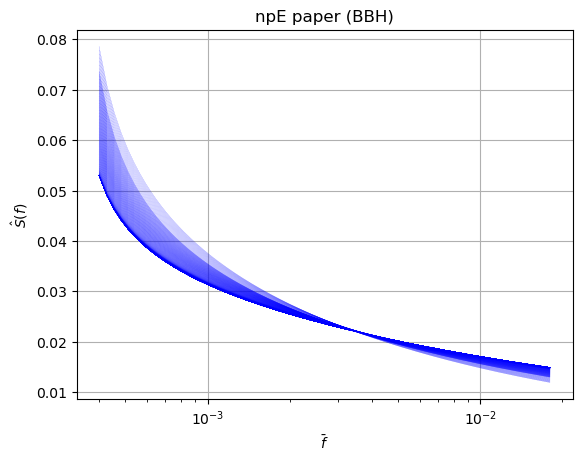

In [20]:
plot_dephasing(example_network_path, network_type='BBH', title='npE paper (BBH)', z_ang_min=1., z_ang_max=1.5)

z1:  (360,)
z2:  (360,)


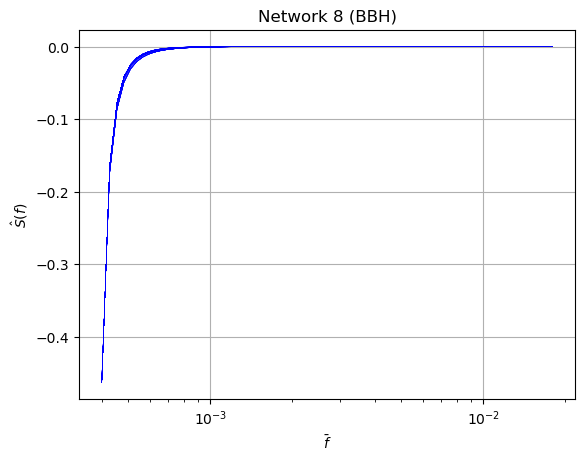

In [19]:
plot_dephasing(BBH_network_path_8, network_type='BBH', title='Network 8 (BBH)', z_ang_min=1., z_ang_max=1.5)

z1:  (360,)
z2:  (360,)


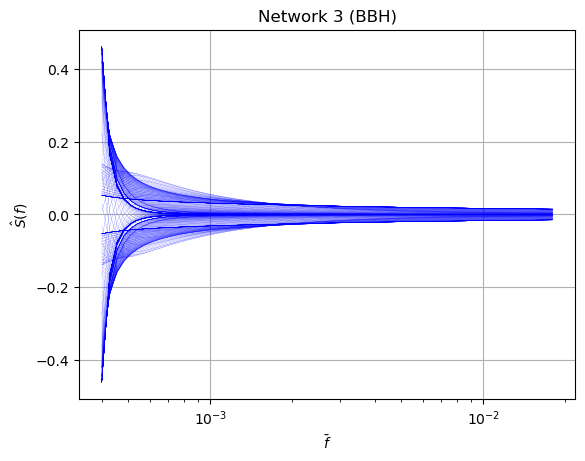

In [8]:
plot_dephasing(BBH_network_path_3, network_type='BBH', title='Network 3 (BBH)')

z1:  (360,)
z2:  (360,)


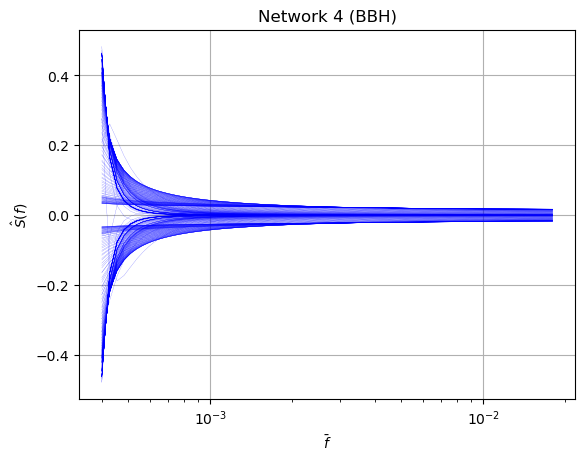

In [9]:
plot_dephasing(BBH_network_path_4, network_type='BBH', title='Network 4 (BBH)')

z1:  (360,)
z2:  (360,)


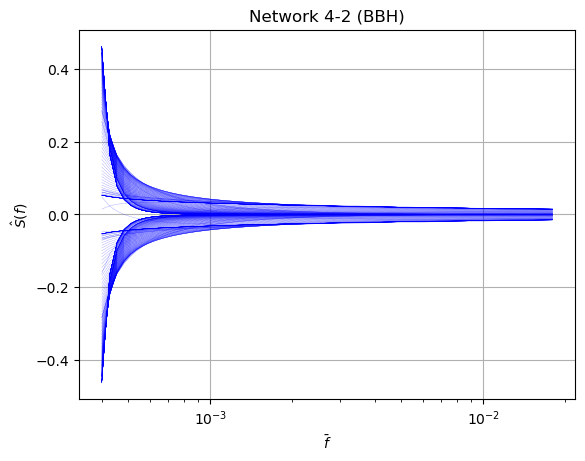

In [11]:
plot_dephasing(BBH_network_path_4_2, network_type='BBH', title='Network 4-2 (BBH)')

z1:  (360,)
z2:  (360,)


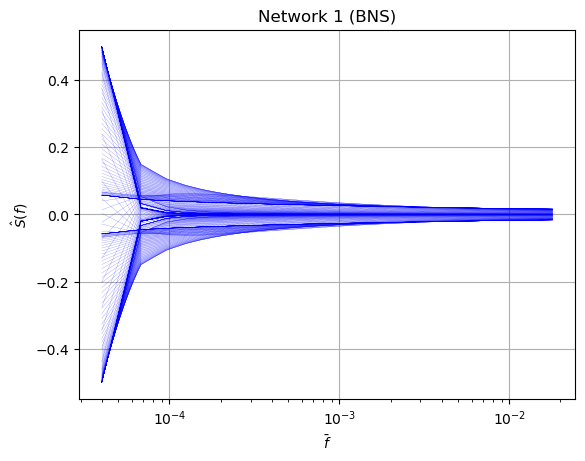

In [9]:
plot_dephasing(BNS_network_path_1, network_type='BNS', title='Network 1 (BNS)')

z1:  (360,)
z2:  (360,)


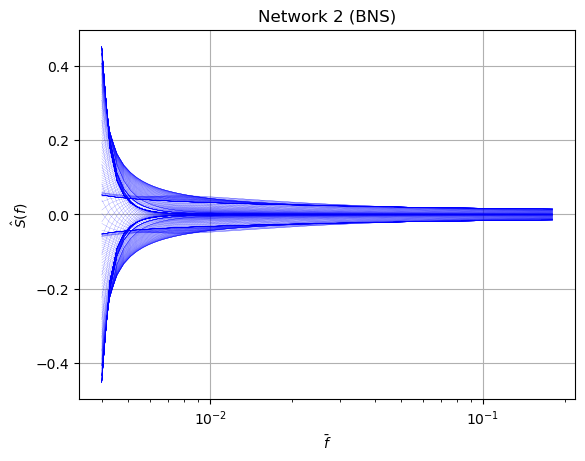

In [6]:
plot_dephasing(BNS_network_path_2, network_type='BNS', title='Network 2 (BNS)')

### Debug plots

z1:  (360,)
z2:  (360,)


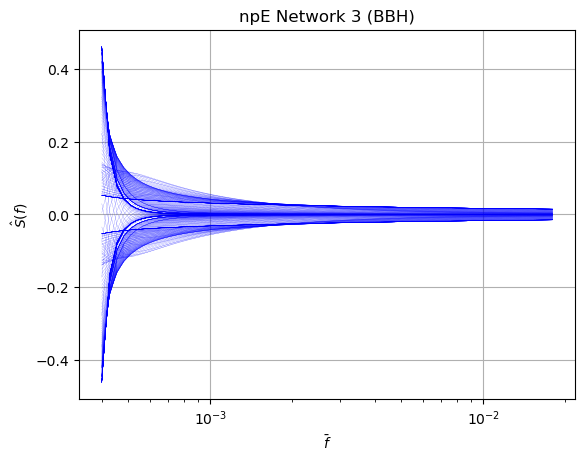

In [15]:
plot_dephasing(BBH_network_path_3, network_type='BBH', title='npE Network 3 (BBH)')

z1:  (360,)
z2:  (360,)


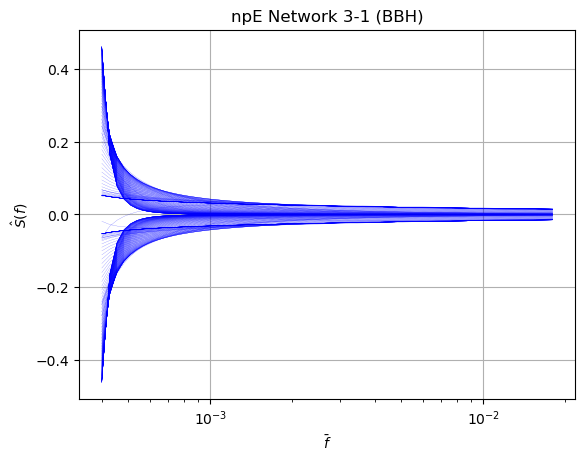

In [16]:
plot_dephasing(BBH_network_path_3_1, network_type='BBH', title='npE Network 3-1 (BBH)')

z1:  (360,)
z2:  (360,)


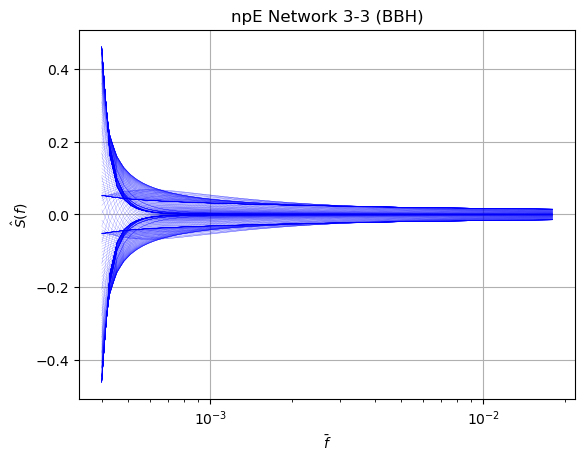

In [17]:
plot_dephasing(BBH_network_path_3_3, network_type='BBH', title='npE Network 3-3 (BBH)')

z1:  (360,)
z2:  (360,)


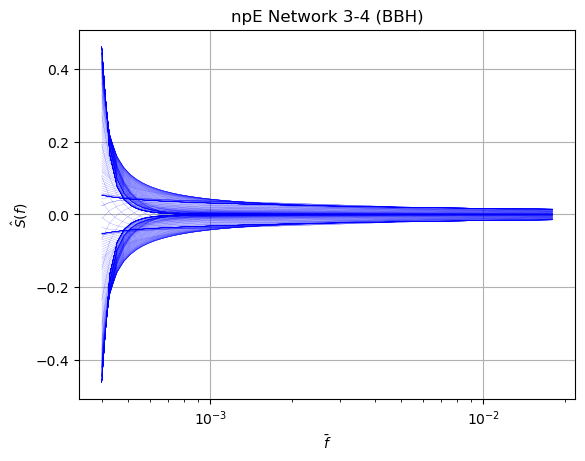

In [18]:
plot_dephasing(BBH_network_path_3_4, network_type='BBH', title='npE Network 3-4 (BBH)')

z1:  (360,)
z2:  (360,)


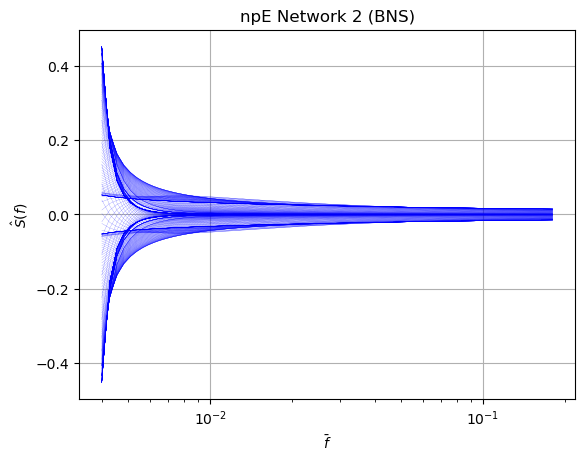

In [7]:
plot_dephasing(BNS_network_path_2, network_type='BNS', title='npE Network 2 (BNS)')

## Plot Latent Space

In [ ]:
# Dataset loading imports
from data import DatasetManager, PhasingDataset
from train_network import DataLoader
# Latent space plotting imports
from utils.train import VAEEvaluationAgent, plot_latent_distrib
from utils.workflow import get_current_epoch_value
from train_network import vae_loss_fn, vae_diagnosis_fn


# Validation dataset
def get_val_dataloader(base_path=project_path, network_type='BBH', seed=1234):
    return get_dataloader(base_path, network_type, subset='val', dataset_seed=seed)

def get_val_dataset(base_path=project_path, network_type='BBH', seed=1234):
    return get_val_dataloader(base_path, network_type, seed).dataset

# Train dataset
def get_train_dataloader(base_path=project_path, network_type='BBH', seed=1234):
    return get_dataloader(base_path, network_type, subset='train', dataset_seed=seed)

def get_train_dataset(base_path=project_path, network_type='BBH', seed=1234):
    return get_train_dataloader(base_path, network_type, seed).dataset

# Test dataset
def get_test_dataloader(base_path=project_path, network_type='BBH', seed=1234):
    return get_dataloader(base_path, network_type, subset='test', dataset_seed=seed)

def get_test_dataset(base_path=project_path, network_type='BBH', seed=1234):
    return get_test_dataloader(base_path, network_type, seed).dataset

# Function to import a dataset from a file
def get_dataloader(base_path=project_path, network_type='BBH', dataset_seed=1234, subset=None):
    if network_type == 'BNS':
        network_type_short = 'NS'
        dataset_filenames = [
            "ppe-minus13.pkl",
            "ppe-minus12.pkl",
            "ppe-minus11.pkl",
            "ppe-minus10.pkl",
            "ppe-minus9.pkl",
            "ppe-minus8.pkl",
            "ppe-minus7.pkl",
            "ppe-minus6.pkl",
            "ppe-minus5.pkl",
            "ppe-minus4.pkl",
            "ppe-minus3.pkl",
            "ppe-minus2.pkl",
            "ppe-minus1.pkl",
        ]
    else:
        network_type_short = 'BH'
        dataset_filenames = [
            "ppe-minus13.pkl",
            "ppe-minus12.pkl",
            "ppe-minus11.pkl",
            "ppe-minus10.pkl",
            "ppe-minus9.pkl",
            "ppe-minus8.pkl",
            "ppe-minus7.pkl",
            "ppe-minus6.pkl",
            "ppe-minus5.pkl",
            "ppe-minus4.pkl",
            "ppe-minus3.pkl",
            "ppe-minus2.pkl",
            "ppe-minus1.pkl",
        ]

    dataset_rootdir = os.path.expanduser(os.path.join(base_path, 'dataset_'+network_type_short))
    #print('Loading dataset from: ', dataset_rootdir)

    dataset_type = PhasingDataset
    dataset_n_ppe = 1
    dataset_norm_fac = {}
    dataset_sample_size = 0.25
    dataset_subset_split = [0.8, 0.1, 0.1]

    dataset_and_split = DatasetManager(
                dataset_filenames, root_dir=dataset_rootdir, 
                sample_size=dataset_sample_size, subset_split=dataset_subset_split, random_state=dataset_seed, 
                dataset_type=dataset_type, dataset_kwargs=dict(n_ppe=dataset_n_ppe, norm_fac=dataset_norm_fac))
        
    batch_size_train = 64
    batch_size_val = 1024
    batch_size_test = 64    # Assumption/guess
    batches_per_summary = 0.1

    dataset_train, dataset_val, dataset_test = dataset_and_split.subsets
    
    if subset is None:
        return (dataset_train, dataset_val, dataset_test)
    if subset in ['train', 'training']:
        data_loader_train = DataLoader(dataset_train, batch_size=batch_size_train, shuffle=True)
        return data_loader_train
    if subset in ['val', 'validation']:
        data_loader_val = DataLoader(dataset_val, batch_size=batch_size_val, shuffle=False)
        return data_loader_val
    if subset in ['test', 'testing', 'tune', 'tuning']:
        data_loader_test = DataLoader(dataset_test, batch_size=batch_size_test, shuffle=False)
        return data_loader_test

def plot_latent_space(network_path, base_path=project_path, network_type='BBH', dataset_seed=1234, use_final_kwargs=True,
                      z_theta_inj=None, z_theta_rec=None, z_abs_inj=None, z_abs_rec=None):

    # Import network from file
    model, device, optimizer, scheduler = import_network(network_path, base_path)

    # State loss function and diagnosis function of interest
    loss_fn = vae_loss_fn
    diagnosis_fn = vae_diagnosis_fn

    # Use kwargs from shape function training
    if not use_final_kwargs:
        loss_kwargs = dict(
            kl_coeff=1e-6, 
            shape_coeff=1., scale_coeff=0., 
            recon_coeff=0., recon_scale_coeff=0.,
            with_mu=False, recon_use_mse=False, 
        )
        diagnosis_kwargs = dict(with_mu=False)
    else:
        # Use kwargs from scale function training
        loss_kwargs = dict(
            kl_coeff=0., 
            shape_coeff=0., scale_coeff=0., 
            recon_coeff=0., recon_scale_coeff=1.,
            with_mu=False, recon_use_mse=False, 
        )
        diagnosis_kwargs = dict(with_mu=False)

    # Define total epochs and current epoch (final)
    epochs_per_latent_plot = [(10, 1), (None, 10)]
    epochs_per_checkpoint = 50
    final_epoch = 100
        
    current_epochs_per_latent_plot = get_current_epoch_value(epochs_per_latent_plot, final_epoch)
    current_epochs_per_checkpoint = get_current_epoch_value(epochs_per_checkpoint, final_epoch)

    current_loss_kwargs = dict()
    for k,v in loss_kwargs.items():
        current_loss_kwargs[k] = get_current_epoch_value(v, final_epoch)

    print('Importing Datasets...')
    # Get training and validation sets used for network training
    data_loader_train = get_train_dataloader(base_path, network_type, dataset_seed)
    data_loader_val = get_val_dataloader(base_path, network_type, dataset_seed)

    # Print some dataset info
    if True:
        #print(data_loader_val.dataset)
        print(f'Dataset type: {type(data_loader_val.dataset)}')
        print(f'Number of samples: {len(data_loader_val.dataset)}')
        print(f'Example data shape: {data_loader_val.dataset[0][0].shape}')
        print(f'Example labels:')
        print(f'    m1: {data_loader_val.dataset[0][1][0]}')
        print(f'    m2: {data_loader_val.dataset[0][1][1]}')
        print(f'    s1: {data_loader_val.dataset[0][1][2]}')
        print(f'    s2: {data_loader_val.dataset[0][1][3]}')

    #training_seed = None
    #torch.manual_seed(training_seed)

    # Latent space plot parameters
    npoints_for_latent_plot = int(1e2)
    npoints_for_generation = 16
 
    print('Constructing Agent...')
    # Establish VAE Evaluation Agent from loaded model and dataset
    agent = VAEEvaluationAgent(
                            model, loss_fn, diagnosis_fn, current_loss_kwargs, diagnosis_kwargs,
                            distrib_thin_fac=npoints_for_latent_plot/len(data_loader_val.dataset),
                            sample_size=npoints_for_generation)

    # Get hyperparameters at this epoch
    hparams = dict(
            lr=scheduler.get_last_lr()[0], 
            weight_decay=optimizer.defaults['weight_decay'],
            batch_size=data_loader_train.batch_size,
        )
    # hparams.update(agent.loss_fn_kwargs)
    for k, v in agent.loss_fn_kwargs.items():
        try: float(v)
        except TypeError: pass
        else: hparams[k] = v
    #log_str = "{} Epoch {}".format(datetime.now().strftime('%H:%M:%S'), final_epoch)
    #log_str += "\nHparams = {}".format(hparams)
    #print(log_str); sys.stdout.flush()

    print('Training agent...')
    # Agent train step
    if True:
        agent.train()
        for i_batch, data_batch in enumerate(data_loader_train):
            optimizer.zero_grad()
            loss = agent.add_batch(data_batch)
            if torch.isfinite(loss):
                loss.backward()
                optimizer.step()
            #if batches_per_summary > 0 and (i_batch+1) % batches_per_summary == 0:
                #loss_recent = agent.pop_recent_loss()
                #log_str = "  {:0.0f}%, interval loss = {:0.3e}".format(
                #                    100. * (i_batch+1) / len(data_loader_train), loss_recent)
                #print(log_str); sys.stdout.flush()
        scheduler.step()

        #loss_train = agent.report_loss()

    print('Evaluating Agent...')
    # Agent evaluation step
    agent.eval()
    for i_batch, data_batch in enumerate(data_loader_val):
        agent.add_batch(data_batch)
    #loss_val = agent.report_loss()
    #metrics = agent.report_metrics()

    print('Plotting Latent Space distribution...')
    # Plot latent space distribution

    if False:
        #print('Agent plot')
        fig_latent = agent.report_latent_distrib()
    else:
        #print('Manual plot')
        distrib = {k: np.concatenate(agent._acc_distrib[k], axis=0) for k in agent._distrib_keys}
        fig_latent = plot_latent_distrib(distrib, plot_masked=False)

    if False:
        # WIP: Plot sample values as projected onto latent space
        from waveform_analysis import PhaseModificationAnalysis
        model_kwargs = dict(depth=4, width=512, data_dim=640, grid_dim=2, freeze_shape=True)
        network_fullpath = os.path.expanduser(os.path.join(base_path, network_path))
        val_dataset_analysis = PhaseModificationAnalysis(network_fullpath, model_kwargs=model_kwargs)

        def extract_latent_from_data(dataset_item):
            phases = dataset_item[0]
            labels = dataset_item[1]
            b_ppe, gamma_bar = dataset_item[2]
            #mtot = mass_1 + mass_2
            #freqs = 10**val_dataset_analysis.model_loggeom_freqs / mtot / MSUN_S
            #phases = phase_func(freqs) / self.norm_fac
            norm = np.sqrt(np.mean(phases*phases, axis=-1))
            if norm == 0.:
                return 0., 0.
            phases = torch.tensor(phases, dtype=torch.double, device=val_dataset_analysis.device).view(1, 1, -1)
            labels = val_dataset_analysis.gw_params_to_vae_labels(labels[0], labels[1], labels[2], labels[3])
            labels = torch.tensor(labels, dtype=torch.double, device=val_dataset_analysis.device).view(1, -1)
            z, _ = val_dataset_analysis.model.encoder(phases, labels)
            norm_std = val_dataset_analysis.model.decoder(z, labels)
            norm_std = torch.sqrt(torch.mean(norm_std*norm_std, dim=-1)).squeeze().item()
            z_1, z_2 = z.cpu().detach().numpy().flatten() * norm / norm_std
            return z_1, z_2, b_ppe

        plot_values = np.array([extract_latent_from_data(dataset_item) for dataset_item in data_loader_val.dataset])
        ax_latent = fig_latent.get_axes()
        ax_latent[0].scatter(x=plot_values[:,0], y=plot_values[:,1], figure=fig_latent)
        #  labels=plot_values[:,2]

    if z_abs_inj is not None and z_theta_inj is not None:
        z_1_inj = z_abs_inj * np.cos(z_theta_inj)
        z_2_inj = z_abs_inj * np.sin(z_theta_inj)
        ax_latent = fig_latent.get_axes()
        ax_latent[0].scatter(x=[z_1_inj], y=[z_2_inj], figure=fig_latent, marker='h', label='Injected')

    if z_abs_rec is not None and z_theta_rec is not None:
        z_1_rec = z_abs_rec * np.cos(z_theta_rec)
        z_2_rec = z_abs_rec * np.sin(z_theta_rec)
        ax_latent = fig_latent.get_axes()
        ax_latent[0].scatter(x=[z_1_rec], y=[z_2_rec], figure=fig_latent, marker='x', label='Recovered')

    #plt.legend()
    #plt.tight_layout()
    #plt.show()

### Example plots

In [7]:
# Example network paths
example_network_path = './npe/utils/param_estimation_test/npe_network.pt'   # Example network
BBH_network_path = './network/checkpoints/npe-BH/npe-BH_100-epochs.pt'  # BBH network
BBH_network_path_3 = './network/checkpoints/npe-BH-3/npe-BH_100-epochs.pt'  # BBH network 3
BBH_network_path_3_1 = './network/checkpoints/npe-BH-3-1/npe-BH_100-epochs.pt'  # BBH network 3-1
BBH_network_path_3_4 = './network/checkpoints/npe-BH-3-4/npe-BH_100-epochs.pt'  # BBH network 3-4
BBH_network_path_4 = './network/checkpoints/npe-BH-4/npe-BH_100-epochs.pt'  # BBH network 4
BNS_network_path = './network/checkpoints/npe-NS/npe-NS_100-epochs.pt'  # BNS network

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.3208290329065626
    m2: 0.29545006367958093
    s1: -0.7602675237514681
    s2: 0.1880145901980944
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


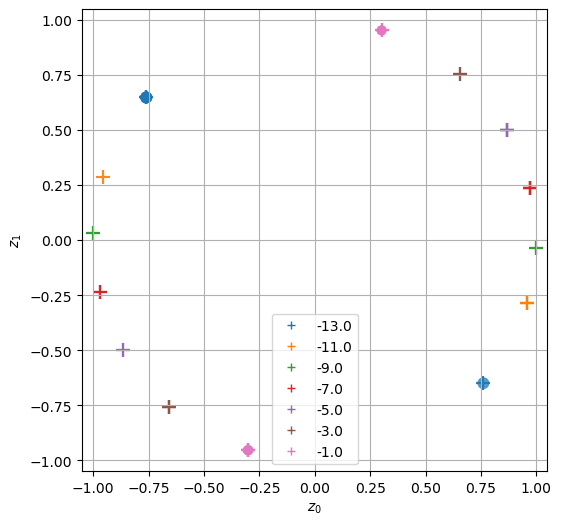

In [8]:
plot_latent_space(example_network_path, dataset_seed=1234)

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.40048366418261
    m2: 0.346521821608006
    s1: 0.13679317043436928
    s2: -0.2844898284632033
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


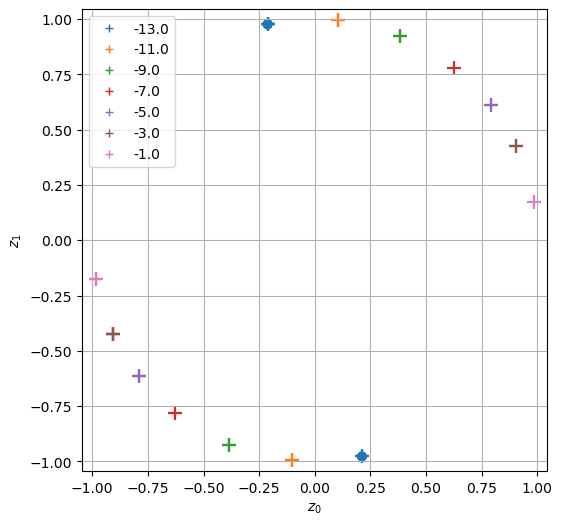

In [ ]:
plot_latent_space(BBH_network_path, dataset_seed=1234)

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.40048366418261
    m2: 0.346521821608006
    s1: 0.13679317043436928
    s2: -0.2844898284632033
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


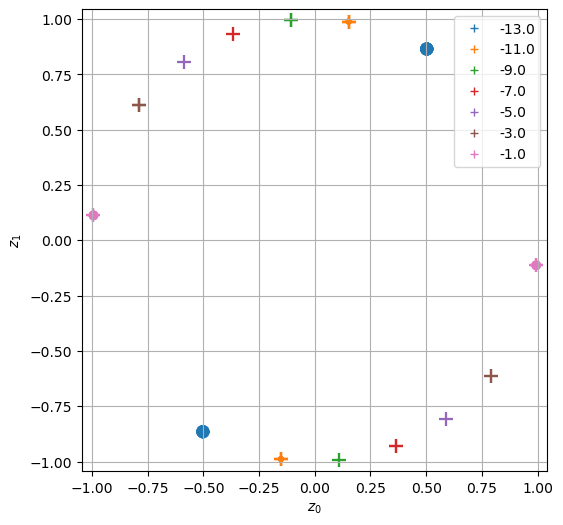

: 

In [ ]:
plot_latent_space(BNS_network_path, dataset_seed=1234)

### Debug Examples

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.40048366418261
    m2: 0.346521821608006
    s1: 0.13679317043436928
    s2: -0.2844898284632033
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


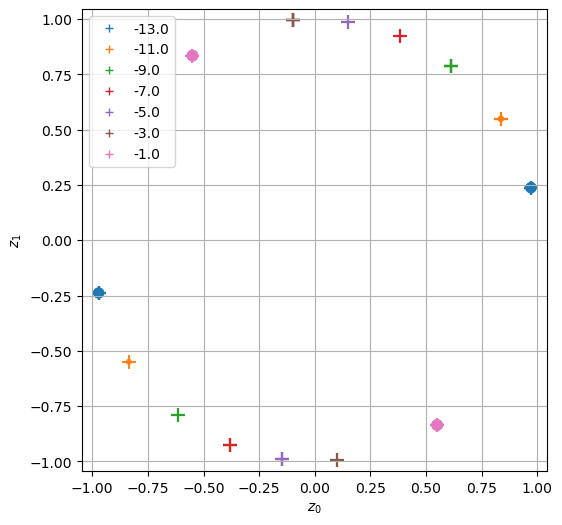

: 

In [ ]:
plot_latent_space(BBH_network_path_3, dataset_seed=1234)

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.4579752351240076
    m2: 0.9012066083886463
    s1: 0.3066728760808617
    s2: -0.427912220357481
Constructing Agent...
Training agent...
Evaluating Agent...
Plotting Latent Space distribution...


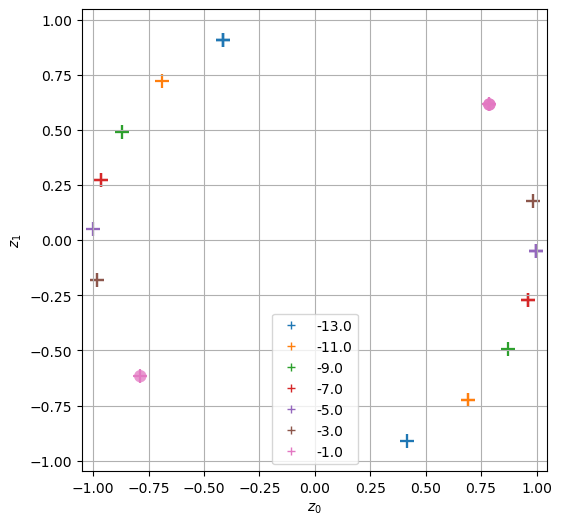

: 

In [ ]:
plot_latent_space(BBH_network_path_3_1, dataset_seed=1234)

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.4579752351240076
    m2: 0.9012066083886463
    s1: 0.3066728760808617
    s2: -0.427912220357481
Constructing Agent...
Training agent...
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> 

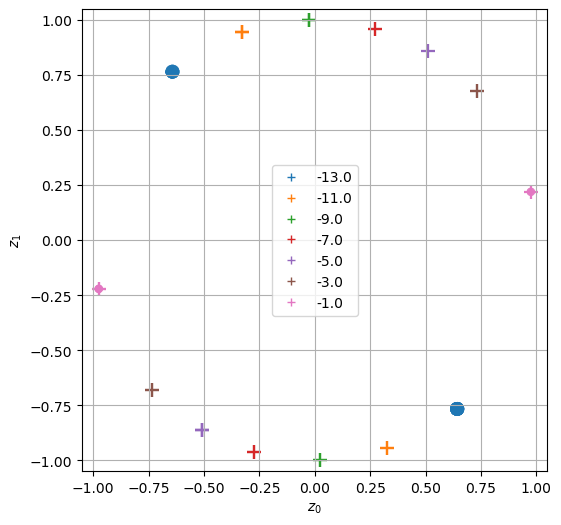

In [13]:
plot_latent_space(BBH_network_path_3_4, dataset_seed=1234)

Importing Datasets...
Dataset type: <class 'torch.utils.data.dataset.Subset'>
Number of samples: 17500
Example data shape: (1, 640)
Example labels:
    m1: 2.8918502714180496
    m2: 0.5030635905138438
    s1: -0.3960982564441269
    s2: 0.44557790831542476
Constructing Agent...
Training agent...
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --

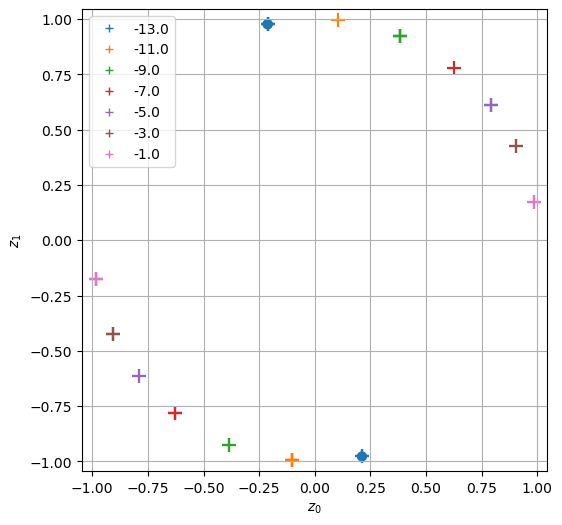

In [15]:
plot_latent_space(BBH_network_path_4, dataset_seed=4321)

## Compare Reconstructed phi_ppE

In [7]:
from waveform_analysis import PhaseModificationAnalysis
import bilby
from bilby.gw.conversion import (
    component_masses_to_chirp_mass, 
    component_masses_to_symmetric_mass_ratio,
)
import lalsimulation
from astropy import units as u, constants as c

def get_phi_ppe(frequency_array, mass_1, mass_2, chi_1, chi_2, b, beta):
    mtot = mass_1 + mass_2
    mc = component_masses_to_chirp_mass(mass_1, mass_2)
    freqs = np.asarray(frequency_array, dtype=np.float64)
    fcut = 1.8e-2 / mtot / MSUN_S
    freqs_geom = np.pi * freqs * mc * MSUN_S
    fcut_geom = np.pi * fcut * mc * MSUN_S
    mask_low = freqs <= 0.
    mask_high = freqs > fcut
    mask_mid = ~(mask_low|mask_high)
    phi = np.zeros_like(freqs)
    phi[mask_mid] = beta * freqs_geom[mask_mid] ** (b/3.)
    phicut = beta * fcut_geom ** (b/3.)
    dphicut = phicut / fcut_geom * (b/3.)
    phi[mask_high] = phicut + dphicut * (freqs_geom[mask_high] - fcut_geom)
    return phi

def compare_reconstructed_phasing(network_path, base_path=project_path, b_inj=-5, beta_rel_inj=0.5,
                                  plot_difference=False, network_type='BBH'):
    # Import Network
    network_file = os.path.expanduser(os.path.join(base_path, network_path))
    network_kwargs = dict(depth=4, width=512,
                        data_dim=640, grid_dim=2)
    if network_type == 'BNS':
        fmin = 0.00004
    else:
        fmin = 0.0004
    vae_analyzer = PhaseModificationAnalysis(network_file, network_kwargs, min_fgeom=fmin)

    def get_vae_latent(m1, m2, chi1, chi2, b, beta):
        phi_func = lambda freqs: get_phi_ppe(freqs, m1, m2, chi1, chi2, b, beta)
        z1, z2 = vae_analyzer.extract_latent(phi_func, m1, m2, chi1, chi2)
        return z1, z2

    def get_ppe_bound(m1, m2, chi1z, chi2z, b_ppe, ppe_ref=10):
        ppe_ref = ppe_ref * u.Hz * (m1 + m2) * u.solMass
        ppe_ref = ppe_ref * c.G / c.c**3
        ppe_ref = ppe_ref.to('').value
        ppe_ref_v = (np.pi * ppe_ref) ** (1/3)
        b_ref = max(-5, int(np.floor(b_ppe)))
        # if b_ref <= -4:
        #     # GR coeff at 0.5PN is 0, merge with the b <= -5 branch
        #     b_ref = -5
        eta = bilby.gw.conversion.component_masses_to_symmetric_mass_ratio(m1, m2)
        num_samples = 1
        param_vecs = [lal.CreateREAL8Vector(num_samples) for _ in range(8)]
        param_vecs[0].data = np.atleast_1d(m1)
        param_vecs[1].data = np.atleast_1d(m2)
        param_vecs[2].data = np.atleast_1d(chi1z)
        param_vecs[3].data = np.atleast_1d(chi2z)
        for i in range(4, 8):
            # tidal deformation and spin deformation
            param_vecs[i].data = np.zeros_like(param_vecs[i].data)
        pn_coeff = lalsimulation.SimInspiralTaylorF2AlignedPhasingArray(*param_vecs).data
        pn_coeff = pn_coeff[:len(pn_coeff)//3] # remove coeffs for vlogv and vlogvsq
        if b_ref != -4:
            pn_coeff = pn_coeff.reshape(-1, num_samples)[b_ref+5] # take only the pn coeff of the ppE order
            beta_ppe_bound = np.abs(pn_coeff) * ppe_ref_v**(b_ref-b_ppe)
        else:
            pn_coeff1 = pn_coeff.reshape(-1, num_samples)[0]
            pn_coeff2 = pn_coeff.reshape(-1, num_samples)[2]
            beta_ppe_bound = np.sqrt(np.abs(pn_coeff1) * np.abs(pn_coeff2))
        beta_ppe_bound /= eta**(b_ppe/5.)
        return beta_ppe_bound[0]
    
    # Example injected waveform
    injection_parameters = dict(
        # # for mtot = 15
        # mass_1=9.,
        # mass_2=6.,
        # luminosity_distance=534.2871037194635,
        # for mtot = 35
        mass_1=21.,
        mass_2=14.,
        luminosity_distance=862.3762176154274,
        chi_1=0.,
        chi_2=0.,
        theta_jn=0.5235987755982988, 
        psi=2.659, 
        phase=1.3, 
        geocent_time=1126259642.413,
        ra=1.375, 
        dec=-1.2108,
    )

    injection_parameters['b'] = b_inj
    ppe_unit = get_ppe_bound(
        injection_parameters['mass_1'], 
        injection_parameters['mass_2'],
        injection_parameters['chi_1'],
        injection_parameters['chi_2'],
        injection_parameters['b'],
        ppe_ref=10)
    injection_parameters['beta'] = beta_rel_inj * ppe_unit
    z1, z2 = get_vae_latent(
            injection_parameters['mass_1'], 
            injection_parameters['mass_2'],
            injection_parameters['chi_1'],
            injection_parameters['chi_2'],
            injection_parameters['b'],
            injection_parameters['beta'])
    #injection_parameters['z_1'] = z1
    #injection_parameters['z_2'] = z2
    #injection_parameters['z_abs'] = np.sqrt(z1*z1 + z2*z2)
    #injection_parameters['z_theta'] = np.mod(np.arctan2(z2, z1), 2*np.pi)

    mc = component_masses_to_chirp_mass(injection_parameters['mass_1'], injection_parameters['mass_2'])
    plot_freqs = 10**(vae_analyzer.model_loggeom_freqs) / (np.pi * mc * MSUN_S)

    print('b', b_inj)
    print('beta', beta_rel_inj*ppe_unit)
    print('z1', z1)
    print('z2', z2)
    print('z_abs', np.sqrt(z1**2 + z2**2))
    print('z_theta', np.mod(np.arctan2(z2, z1), 2*np.pi))
    print('chirp_mass', mc)

    # Get injected phi_ppe
    inject_phi = get_phi_ppe(plot_freqs,
                             injection_parameters['mass_1'], injection_parameters['mass_2'],
                             injection_parameters['chi_1'], injection_parameters['chi_2'],
                             injection_parameters['b'], injection_parameters['beta'])

    # Get reconstructed phi_ppe
    recon_phi = vae_analyzer.phase_mod(plot_freqs,
                                       injection_parameters['mass_1'], injection_parameters['mass_2'],
                                       injection_parameters['chi_1'], injection_parameters['chi_2'],
                                       z1, z2)
    
    # Plot ppE injected phase mod vs. npE reconstruction
    plt.plot(plot_freqs, inject_phi, label='Injected')
    plt.plot(plot_freqs, recon_phi, label='Reconstructed', linestyle=':')
    if plot_difference:
        plt.plot(plot_freqs, inject_phi-recon_phi, label='Difference', linestyle='--')
    
    plt.xlabel('f')
    plt.ylabel('Phi')
    plt.title('ppE vs. npE')
    plt.legend()

    plt.tight_layout
    plt.show()

### Example plots

In [10]:
# Example network paths
example_network_path = './npe/utils/param_estimation_test/npe_network.pt'   # Example network
BBH_network_path = './network/checkpoints/npe-BH/npe-BH_100-epochs.pt'  # BBH network
BBH_network_path_3 = './network/checkpoints/npe-BH-3/npe-BH_100-epochs.pt'  # BBH network (OLD)
BBH_network_path_4 = './network/checkpoints/npe-BH-4/npe-BH_100-epochs.pt'  # BBH network (OLD)
BNS_network_path = './network/checkpoints/npe-NS/npe-NS_100-epochs.pt'  # BNS network

b -3
beta 0.13233182148734615
z1 0.32487935
z2 0.3739468
z_abs 0.4953612718436573
z_theta 0.8554971814155579
chirp_mass 14.86602262312908


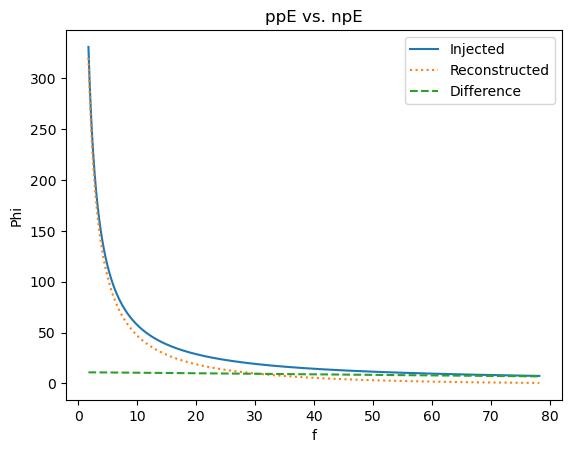

In [47]:
compare_reconstructed_phasing(example_network_path, b_inj=-3, plot_difference=True)

b -5
beta 0.011718749999999998
z1 0.31342873
z2 0.38054818
z_abs 0.4930055631541519
z_theta 0.8818154335021973
chirp_mass 14.86602262312908


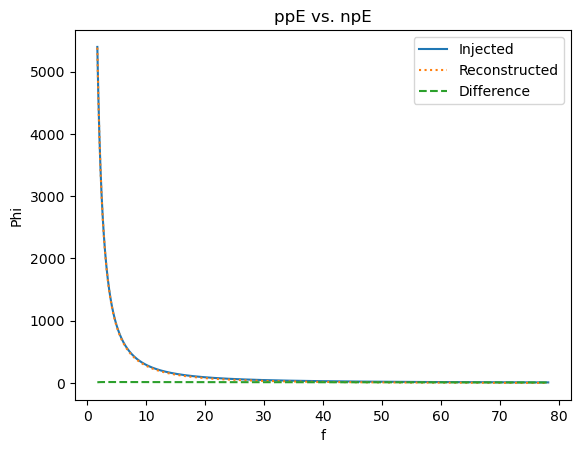

In [ ]:
compare_reconstructed_phasing(BBH_network_path, b_inj=-5, plot_difference=True)

b -3
beta 0.13233182148734615
z1 0.05104977
z2 -0.5073175
z_abs 0.5098795033104235
z_theta 4.812678162251608
chirp_mass 14.86602262312908


/u/loane2/projects/npe/npe/waveform_analysis.py:186: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(filepath, map_location=self.device)[

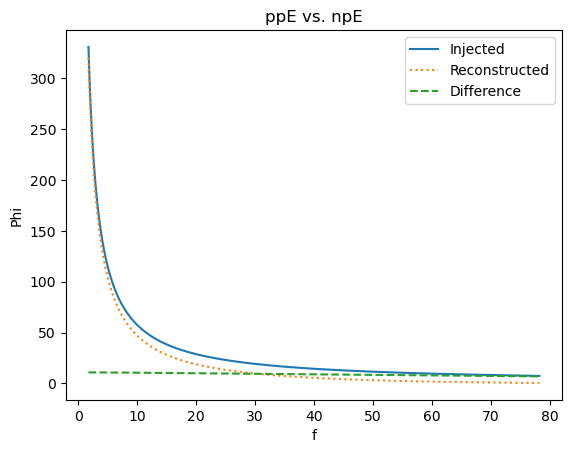

In [ ]:
compare_reconstructed_phasing(BBH_network_path_3, b_inj=-3, plot_difference=True)

b -5
beta 0.011718749999999998
z1 -1.2402755
z2 1.7002363
z_abs 2.10453958549181
z_theta 2.2010297775268555
chirp_mass 14.86602262312908


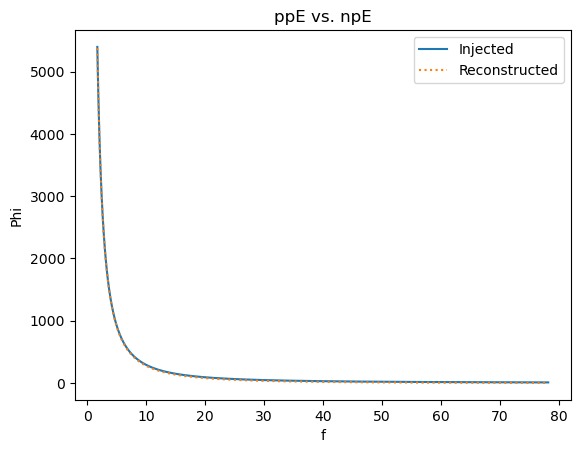

In [ ]:
compare_reconstructed_phasing(BNS_network_path)

### Debug plots

b -2
beta 1.3868337424098105
z1 0.6586278595132903
z2 1.237806282764251
z_abs 1.4021251909076136
z_theta 1.0818052804991258
chirp_mass 14.86602262312908


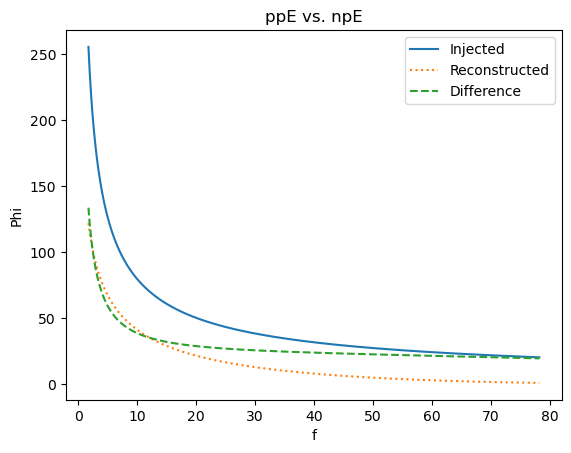

In [30]:
compare_reconstructed_phasing(example_network_path, b_inj=-2, plot_difference=True)

extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
b -5
beta 0.011718749999999998
z1 0.48840317558681634
z2 -0.02450611708995869
z_abs 0.48901759855665045
z_theta 6.233051353227285
chirp_mass 14.86602262312908


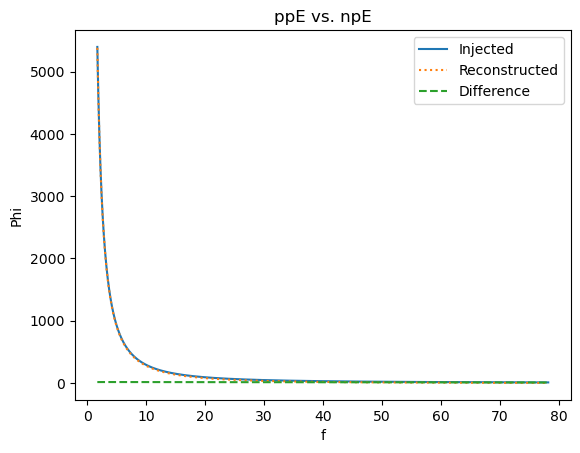

In [17]:
compare_reconstructed_phasing(BBH_network_path_3_1, b_inj=-5, plot_difference=True)

extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
b -5
beta 0.011718749999999998
z1 0.2564007562180096
z2 0.4317087889134016
z_abs 0.502109376743995
z_theta 1.034858942397603
chirp_mass 14.86602262312908


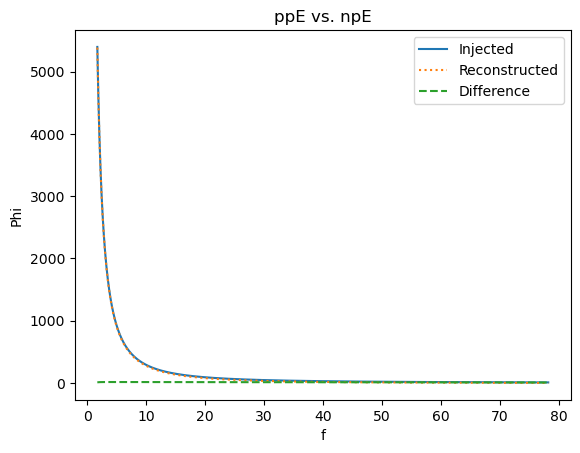

In [18]:
compare_reconstructed_phasing(BBH_network_path_3_4, b_inj=-5, plot_difference=True)

extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
b -2
beta 1.3868337424098105
z1 0.42748679062430406
z2 0.2525656191652213
z_abs 0.4965222534213136
z_theta 0.5336384681110528
chirp_mass 14.86602262312908


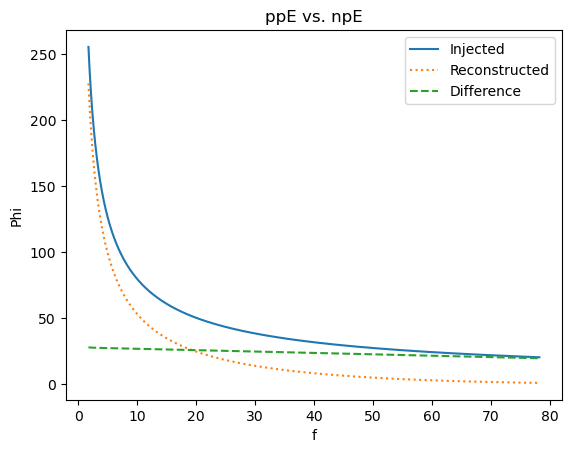

: 

In [ ]:
compare_reconstructed_phasing(BBH_network_path_3_4, b_inj=-2, plot_difference=True)

b -4
beta 0.03937973505567092
z1 -0.4363672315720601
z2 0.45371824935198657
z_abs 0.629505052072575
z_theta 2.3367033055336224
chirp_mass 14.86602262312908


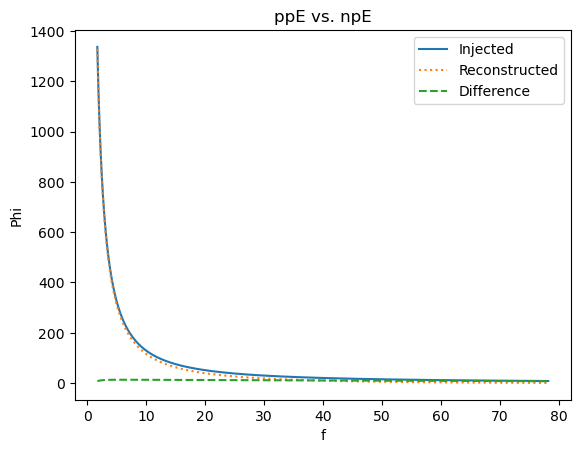

In [21]:
compare_reconstructed_phasing(BNS_network_path_2, b_inj=-4, plot_difference=True)

## Dataset Analysis

In [ ]:
# TODO
# Plot min/max/mean/variance for a given dataset
def dataset_summary(dataset_path):

    # Load dataset
    #pickle

    return None

## Parameter Estimation

In [5]:
# Helper functions
from scipy.interpolate import interp1d
from waveform_analysis import PhaseModificationAnalysis
import bilby
from bilby.gw.conversion import (
    component_masses_to_chirp_mass, 
    component_masses_to_symmetric_mass_ratio,
    chirp_mass_and_mass_ratio_to_component_masses,
    chirp_mass_and_total_mass_to_symmetric_mass_ratio,
)
import lalsimulation
from astropy import units as u, constants as c

# Get beta_ppe_max in order to rescale beta_ppe_rel == beta_ppe / beta_ppe_max,
#   where beta_ppe_max is taken to be the maximum allowable magnitude of modification for a given
#   b_ppe order, after which the ppE formalism is no longer valid.
#   (ppe_ref = reference frequency in Hz)
def get_ppe_bound(m1, m2, chi1z, chi2z, b_ppe, ppe_ref=10):
    ppe_ref = ppe_ref * u.Hz * (m1 + m2) * u.solMass
    ppe_ref = ppe_ref * c.G / c.c**3
    ppe_ref = ppe_ref.to('').value
    ppe_ref_v = (np.pi * ppe_ref) ** (1/3)
    b_ref = max(-5, int(np.floor(b_ppe)))
    # if b_ref <= -4:
    #     # GR coeff at 0.5PN is 0, merge with the b <= -5 branch
    #     b_ref = -5
    eta = bilby.gw.conversion.component_masses_to_symmetric_mass_ratio(m1, m2)
    num_samples = 1
    param_vecs = [lal.CreateREAL8Vector(num_samples) for _ in range(8)]
    param_vecs[0].data = np.atleast_1d(m1)
    param_vecs[1].data = np.atleast_1d(m2)
    param_vecs[2].data = np.atleast_1d(chi1z)
    param_vecs[3].data = np.atleast_1d(chi2z)
    for i in range(4, 8):
        # tidal deformation and spin deformation
        param_vecs[i].data = np.zeros_like(param_vecs[i].data)
    pn_coeff = lalsimulation.SimInspiralTaylorF2AlignedPhasingArray(*param_vecs).data
    pn_coeff = pn_coeff[:len(pn_coeff)//3] # remove coeffs for vlogv and vlogvsq
    if b_ref != -4:
        pn_coeff = pn_coeff.reshape(-1, num_samples)[b_ref+5] # take only the pn coeff of the ppE order
        beta_ppe_bound = np.abs(pn_coeff) * ppe_ref_v**(b_ref-b_ppe)
    else:
        pn_coeff1 = pn_coeff.reshape(-1, num_samples)[0]
        pn_coeff2 = pn_coeff.reshape(-1, num_samples)[2]
        beta_ppe_bound = np.sqrt(np.abs(pn_coeff1) * np.abs(pn_coeff2))
    beta_ppe_bound /= eta**(b_ppe/5.)
    return beta_ppe_bound[0]

def get_vae_latent(vae_analyzer: PhaseModificationAnalysis, m1, m2, chi1, chi2, b, beta):
    phi_func = lambda freqs: get_phi_ppe(freqs, m1, m2, chi1, chi2, b, beta)
    #print('type(phi_func): ', type(phi_func))
    #print('type(phi_func[freqs]): ', phi_func(10**vae_analyzer.model_loggeom_freqs / (m1 + m2) / MSUN_S).dtype)
    #print('type(m1): ', type(m1))
    #print('type(m2): ', type(m2))
    #print('type(chi1): ', type(chi1))
    #print('type(chi2): ', type(chi2))
    #print('type(b): ', type(b))
    #print('type(beta): ', type(beta))
    z1, z2 = vae_analyzer.extract_latent(phi_func, m1, m2, chi1, chi2)
    return z1, z2

def get_ppe_params(vae_analyzer: PhaseModificationAnalysis, m1, m2, chi1, chi2, zabs, ztheta):
    #phi_func = lambda freqs: get_phi_ppe(freqs, m1, m2, chi1, chi2, b, beta)
    #z1, z2 = vae_analyzer.extract_latent(phi_func, m1, m2, chi1, chi2)
    return b, beta

# Interpolate theory angle mappings for injected binary parameters
# b_ppe <--> z_theta
def map_latent_space_angles(vae_analyzer, n_points=100, b_min=-13, b_max=-1, beta_ppe_rel=1.,
                            m1=20., m2=15., chi1=0., chi2=0.):
    b_ppe_vals = np.linspace(b_min, b_max, n_points)
    beta_ppe_units = np.array([get_ppe_bound(m1, m2, chi1, chi2, b_ppe_val) for b_ppe_val in b_ppe_vals])
    beta_ppe_vals = beta_ppe_rel*beta_ppe_units
    latent_space_vals = np.array([get_vae_latent(vae_analyzer, m1, m2, chi1, chi2, b_ppe, beta_ppe) for b_ppe, beta_ppe in zip(b_ppe_vals, beta_ppe_vals)])
    
    z1_vals = latent_space_vals[:,0]
    z2_vals = latent_space_vals[:,1]
    z_abs_vals = np.sqrt(np.abs(z1_vals**2 + z2_vals**2))
    z_theta_vals = np.mod(np.arctan2(z2_vals, z1_vals), 2*np.pi)

    # f[b_ppe] -> z_theta
    theta_func = interp1d(b_ppe_vals, z_theta_vals, fill_value='extrapolate')
    # f[z_theta] -> b_ppe
    b_ppe_func = interp1d(z_theta_vals, b_ppe_vals, fill_value='extrapolate')
    return theta_func, b_ppe_func
    #vae_analyzer.extract_latent()

# Interpolate theory scale mappings for injected binary parameters
# beta_ppe <--> z_abs
def map_latent_space_scales(vae_analyzer, n_points=100, beta_min=-1., beta_max=1., b_ppe=-5.,
                            m1=20., m2=15., chi1=0., chi2=0.):
    beta_ppe_unit = get_ppe_bound(m1, m2, chi1, chi2, b_ppe)
    beta_ppe_vals = np.linspace(beta_min, beta_max, n_points) * beta_ppe_unit
    b_ppe_vals = np.array([b_ppe for beta_ppe in beta_ppe_vals])

    latent_space_vals = np.array([get_vae_latent(vae_analyzer, m1, m2, chi1, chi2, b_ppe, beta_ppe) for b_ppe, beta_ppe in zip(b_ppe_vals, beta_ppe_vals)])
    
    z1_vals = latent_space_vals[:,0]
    z2_vals = latent_space_vals[:,1]
    z_abs_vals = np.sqrt(np.abs(z1_vals**2 + z2_vals**2))
    z_theta_vals = np.mod(np.arctan2(z2_vals, z1_vals), 2*np.pi)

    # beta_ppe -> z_abs
    zabs_func = interp1d(beta_ppe_vals, z_abs_vals, fill_value='extrapolate')
    # z_abs -> beta_ppe
    beta_func = interp1d(z_abs_vals, beta_ppe_vals, fill_value='extrapolate')
    return zabs_func, beta_func
    #vae_analyzer.extract_latent()

In [6]:
# Compare injected/recovered parameters for a run

from bilby.core.result import Result

def get_inj_params(pe_result: Result, vae_analyzer: PhaseModificationAnalysis=None):

    inj_params = pe_result.injection_parameters
    
    if 'b' in inj_params:
        b_inj = inj_params['b']
    else:
        b_inj = None
    if 'beta' in inj_params:
        beta_inj = inj_params['beta']
    else:
        beta_inj = None
    if 'z_abs' in inj_params:
        z_abs_inj = inj_params['z_abs']
    else:
        z_abs_inj = None
    if 'z_theta' in inj_params:
        z_theta_inj = inj_params['z_theta']
    else:
        z_theta_inj = None
    
    if np.all([var is None for var in [b_inj, beta_inj, z_abs_inj, z_theta_inj]]):
        return False
    
    if np.all([var is not None for var in [b_inj, beta_inj, z_abs_inj, z_theta_inj]]):
        return b_inj, beta_inj, z_abs_inj, z_theta_inj
    
    if vae_analyzer is None:
        return b_inj, beta_inj, z_abs_inj, z_theta_inj
    
    # We need binary parameters if we are going to swap between ppE and npE bases
    if np.any([key in inj_params for key in ['mass_1','mass_2']]):
        m1_inj = inj_params['mass_1']
        m2_inj = inj_params['mass_2']
    else:
        mc = inj_params['chirp_mass']
        q  = inj_params['mass_ratio']
        m1_inj, m2_inj = chirp_mass_and_mass_ratio_to_component_masses(mc, q)

    chi1_inj = inj_params['chi_1']
    chi2_inj = inj_params['chi_2']

    bppe_to_ztheta, ztheta_to_bppe = map_latent_space_angles(vae_analyzer, beta_ppe_rel=(beta_inj if beta_inj is not None else z_abs_inj),
                                                             m1=m1_inj, m2=m2_inj, chi1=chi1_inj, chi2=chi2_inj)

    if z_theta_inj is None or z_abs_inj is None:
        if b_inj is not None and beta_inj is not None:
            z1_inj, z2_inj = get_vae_latent(
                    m1_inj,
                    m2_inj,
                    chi1_inj,
                    chi2_inj,
                    b_inj,
                    beta_inj)
            z_abs_inj = np.sqrt(z1_inj*z1_inj + z2_inj*z2_inj)
            z_theta_inj = np.mod(np.arctan2(z2_inj, z1_inj), 2*np.pi)
    else:
        if b_inj is None:
            #z1_inj, z2_inj = get_vae_latent(vae_analyzer, m1_inj, m2_inj, chi1_inj, chi2_inj)
            b_inj = ztheta_to_bppe(z_theta_inj)
        if beta_inj is None:
            #beta_ppe_max = get_ppe_bound(m1_inj, m2_inj, chi1_inj, chi2_inj, b_inj)
            #beta_inj = beta_inj_rel * beta_ppe_max
            
            beta_to_zabs, zabs_to_beta = map_latent_space_scales(vae_analyzer, b_ppe=b_inj,
                                                                 m1=m1_inj, m2=m2_inj, chi1=chi1_inj, chi2=chi2_inj)
            beta_inj = zabs_to_beta(z_abs_inj)
    
    return b_inj, beta_inj, z_abs_inj, z_theta_inj

def get_rec_params(result: Result, vae_analyzer: PhaseModificationAnalysis):
    inj_params = result.injection_parameters
    if 'b' in inj_params:
        b_inj = inj_params['b']
    else:
        b_inj = None
    if 'beta' in inj_params:
        beta_inj = inj_params['beta']
    else:
        beta_inj = None
    if 'z_abs' in inj_params:
        z_abs_inj = inj_params['z_abs']
    else:
        z_abs_inj = None
    if 'z_theta' in inj_params:
        z_theta_inj = inj_params['z_theta']
    else:
        z_theta_inj = None

    
    if 'b' in result.posterior:
        b_rec = result.posterior.b.median()
    else:
        b_rec = None
    if 'beta' in result.posterior:
        beta_rec = result.posterior.beta.median()
    else: 
        beta_rec = None
    if 'z_abs' in result.posterior:
        z_abs_rec = result.posterior.z_abs.median()
    else:
        z_abs_rec = None
    if 'z_theta' in result.posterior:
        z_theta_rec = result.posterior.z_theta.median()
    else:
        z_theta_rec = None
    
    if np.all([var is not None for var in [b_rec, beta_rec, z_abs_rec, z_theta_rec]]):
        return b_rec, beta_rec, z_abs_rec, z_theta_rec

    if vae_analyzer is None:
        return b_rec, beta_rec, z_abs_rec, z_theta_rec
    
    # Get posterior median values for m1, m2, chi1, chi2
    if np.any([key in result.posterior for key in ['mass_1','mass_2']]):
        m1_rec = result.posterior['mass_1'].median()
        m2_rec = result.posterior['mass_2'].median()
    else:
        mc = result.posterior['chirp_mass'].median()
        q  = result.posterior['mass_ratio'].median()
        m1_rec, m2_rec = chirp_mass_and_mass_ratio_to_component_masses(mc, q)
    chi1_rec = result.posterior['chi_1'].median()
    chi2_rec = result.posterior['chi_2'].median()

    # Get injected values for m1, m2, chi1, chi2
    if np.any([key in inj_params for key in ['mass_1','mass_2']]):
        m1_inj = inj_params['mass_1']
        m2_inj = inj_params['mass_2']
    else:
        mc = inj_params['chirp_mass']
        q  = inj_params['mass_ratio']
        m1_inj, m2_inj = chirp_mass_and_mass_ratio_to_component_masses(mc, q)
    chi1_inj = inj_params['chi_1']
    chi2_inj = inj_params['chi_2']

    # TODO: Should we set this based on injected parameters, or recovered ones?
    # (Which is more helpful for the purpose of diagnosing errored runs?)
    if b_rec is None:
        beta_ppe_max = get_ppe_bound(m1_rec, m2_rec, chi1_rec, chi2_rec, b_inj)
    else:
        beta_ppe_max = get_ppe_bound(m1_rec, m2_rec, chi1_rec, chi2_rec, b_rec)
    #beta_ppe_max = get_ppe_bound(m1_inj, m2_inj, chi1_inj, chi2_inj, b_inj)
    beta_inj_rel = np.abs(beta_inj)/beta_ppe_max if beta_inj is not None else None
    beta_rec_rel = np.abs(beta_rec)/beta_ppe_max if beta_rec is not None else None

    # Train mapping according to "true" (injected) parameter relations
    bppe_to_ztheta, ztheta_to_bppe = map_latent_space_angles(vae_analyzer, beta_ppe_rel=(beta_inj_rel if beta_inj_rel is not None else z_abs_inj),
                                                             m1=m1_inj, m2=m2_inj, chi1=chi1_inj, chi2=chi2_inj)
    #bppe_to_ztheta, ztheta_to_bppe = map_latent_space_angles(vae_analyzer, beta_ppe_rel=(beta_rec_rel if beta_rec_rel is not None else z_abs_rec),
    #                                                         m1=m1_rec, m2=m2_rec, chi1=chi1_rec, chi2=chi2_rec)

    if z_theta_rec is None or z_abs_rec is None:
        if b_rec is not None and beta_rec is not None:
            z1_rec, z2_rec = get_vae_latent(
                    m1_rec,
                    m2_rec,
                    chi1_rec,
                    chi2_rec,
                    b_rec,
                    beta_rec)
            z_abs_rec = np.sqrt(z1_rec*z1_rec + z2_rec*z2_rec)
            z_theta_rec = np.mod(np.arctan2(z2_rec, z1_rec), 2*np.pi)
    else:
        if b_rec is None:
            #z1_rec, z2_rec = get_vae_latent(vae_analyzer, m1_inj, m2_inj, chi1_inj, chi2_inj)
            b_rec = ztheta_to_bppe(z_theta_rec)
        if beta_rec is None:
            #beta_ppe_max = get_ppe_bound(m1_inj, m2_inj, chi1_inj, chi2_inj, b_rec)
            #beta_rec = beta_rec_rel * beta_ppe_max
            
            # Train mapping according to "true" (injected) parameter relations
            beta_to_zabs, zabs_to_beta = map_latent_space_scales(vae_analyzer, b_ppe=b_inj,
                                                                 m1=m1_inj, m2=m2_inj, chi1=chi1_inj, chi2=chi2_inj)
            #beta_to_zabs, zabs_to_beta = map_latent_space_scales(vae_analyzer, b_ppe=b_rec,
            #                                                     m1=m1_rec, m2=m2_rec, chi1=chi1_rec, chi2=chi2_rec)
            beta_rec = zabs_to_beta(z_abs_rec)
    
    return b_rec, beta_rec, z_abs_rec, z_theta_rec

def compare_params(result_name, network_name=None, verbosity=1, root_path=project_path, network_type='BBH'):
    if network_name is None:
        vae_analyzer = None
    else:
        network_file = os.path.abspath(os.path.expanduser(os.path.join(root_path, '.', network_name)))
        network_kwargs = dict(depth=4, width=512,
                            data_dim=640, grid_dim=2)
        if verbosity >= 2:
            print('network_file: ', network_file)
        if network_type == 'BNS':
            fmin = 0.00004
        else:
            fmin = 0.0004
        vae_analyzer = PhaseModificationAnalysis(network_file, network_kwargs, min_fgeom=fmin)

    result_file = os.path.abspath(os.path.expanduser(os.path.join(root_path, 'logs', 'pe', result_name, 'npe-pe_result.json')))
    if verbosity >= 2:
        print('result_file: ', result_file)
    pe_result = Result.from_json(result_file)

    b_ppe_inj, beta_ppe_inj, z_abs_inj, z_theta_inj = get_inj_params(pe_result, vae_analyzer)
    #print('b_ppe_inj: ', b_ppe_inj)
    #print(type(b_ppe_inj))

    b_ppe_rec, beta_ppe_rec, z_abs_rec, z_theta_rec = get_rec_params(pe_result, vae_analyzer)
    #print('b_ppe_rec: ', b_ppe_rec)
    #print(type(b_ppe_rec))

    if verbosity >= 1:
        if verbosity >= 2:
            print('------------------------------------------------------')
        print('b_ppe:')
        print('   inj: %.2f     rec: %.2f' % (b_ppe_inj, b_ppe_rec))
        print('beta_ppe:')
        print('   inj: %.2e     rec: %.2e' % (beta_ppe_inj, beta_ppe_rec))
        print('z_theta:')
        print('   inj: %.2f     rec: %.2f' % (z_theta_inj, z_theta_rec))
        print('z_abs:')
        print('   inj: %.2f     rec: %.2f' % (z_abs_inj, z_abs_rec))

    result_dict = {'b_ppe_inj': b_ppe_inj, 'b_ppe_rec': b_ppe_rec, 'beta_ppe_inj': beta_ppe_inj, 'beta_ppe_rec': beta_ppe_rec,
                   'z_theta_inj': z_theta_inj, 'z_theta_rec': z_theta_rec, 'z_abs_inj': z_abs_inj, 'z_abs_rec': z_abs_rec}
    
    return result_dict

### Example plots

In [9]:
# Example network paths
example_network_path = './npe/utils/param_estimation_test/npe_network.pt'   # Example network
BBH_network_path = './network/checkpoints/npe-BH/npe-BH_100-epochs.pt'  # BBH network
BBH_network_path_3 = './network/checkpoints/npe-BH-3/npe-BH_100-epochs.pt'  # BBH network 3 (OLD)
BBH_network_path_3_1 = './network/checkpoints/npe-BH-3-1/npe-BH_100-epochs.pt'  # BBH network 3-1
BBH_network_path_4 = './network/checkpoints/npe-BH-4/npe-BH_100-epochs.pt'  # BBH network 4 (OLD)
BBH_network_path_5 = './network/checkpoints/npe-BH-7/npe-BH_100-epochs.pt'  # BBH network 5
BBH_network_path_7 = './network/checkpoints/npe-BH-7/npe-BH_100-epochs.pt'  # BBH network 7
BNS_network_path = './network/checkpoints/npe-NS/npe-NS_100-epochs.pt'  # BNS network
BNS_network_path_2 = './network/checkpoints/npe-NS-2/npe-NS_100-epochs.pt'  # BNS network 2

In [11]:
_ = compare_params('npe_network', example_network_path)
plot_dephasing(example_network_path, title='npE Example Network')
compare_reconstructed_phasing(example_network_path, b_inj=-5, beta_rel_inj=0.5, plot_difference=True)
plot_latent_space(example_network_path, dataset_seed=1234)

extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
extract_latent --> dtype(phases) torch.float64
extract_latent --> dtype(labels) torch.float64
encoder --> dtype(x) torch.float64
encoder --> dtype(cond) torch.float64
forward --> dtype(x) torch.float64
forward --> dtype(cond) torch.float64
extract_latent --> dtype(phases) torch.f

RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Double

In [16]:
_ = compare_params('npe_network_1.5PN', example_network_path)

type(beta_ppe_vals):  float64
b_ppe:
   inj: -2.00     rec: -1.67
beta_ppe:
   inj: 1.39e+00     rec: 2.40e-01
z_theta:
   inj: 1.08     rec: 1.51
z_abs:
   inj: 1.40     rec: 0.73


In [26]:
params_3 = compare_params('npe_BBH_3_OLD', BBH_network_path_3)

#plot_latent_space(BBH_network_path_3, dataset_seed=1234, network_type='BBH',
#                  z_theta_inj=params_3['z_theta_inj'], z_abs_inj=params_3['z_abs_inj'])

type(beta_ppe_vals):  float64
b_ppe:
   inj: -5.00     rec: -15.99
beta_ppe:
   inj: 1.17e-02     rec: -4.11e-03
z_theta:
   inj: 5.00     rec: 2.90
z_abs:
   inj: 0.49     rec: 0.86


In [ ]:
params_3_1 = compare_params('npe_BBH_3-1', BBH_network_path_3_1)

#plot_latent_space(BBH_network_path_3_1, dataset_seed=1234, network_type='BBH',
#                  z_theta_inj=params_3_1['z_theta_inj'], z_abs_inj=params_3_1['z_abs_inj'])

type(beta_ppe_vals):  float64
b_ppe:
   inj: -5.00     rec: -10.84
beta_ppe:
   inj: 1.17e-02     rec: -8.00e-03
z_theta:
   inj: 6.23     rec: 4.33
z_abs:
   inj: 0.49     rec: 0.83


In [34]:
params_4 = compare_params('npe_BBH_4', BBH_network_path_4)

type(beta_ppe_vals):  float64
b_ppe:
   inj: -5.00     rec: -5.00
beta_ppe:
   inj: 1.17e-02     rec: 8.54e-03
z_theta:
   inj: 0.66     rec: 0.66
z_abs:
   inj: 0.50     rec: 0.49


In [32]:
params_5 = compare_params('npe_BBH_5', BBH_network_path_5)

type(beta_ppe_vals):  float64
b_ppe:
   inj: -5.00     rec: -10.35
beta_ppe:
   inj: 1.17e-02     rec: -1.38e-02
z_theta:
   inj: 0.53     rec: 0.54
z_abs:
   inj: 0.50     rec: 0.58


In [34]:
params_6 = compare_params('npe_BNS_2', BNS_network_path_2)

OSError: No result '/u/loane2/projects/npe/logs/pe/npe_BNS_2/npe-pe_result.json' found

## beta_rel vs z_abs

In [ ]:
# Plot beta_rel vs z_abs for each b_ppe on the same plot



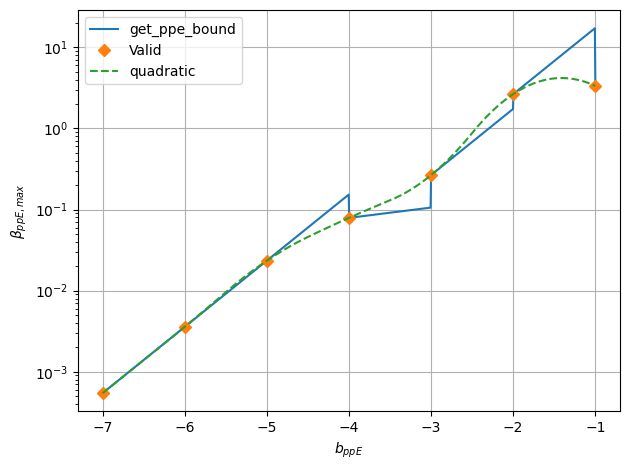

In [ ]:
# Plot beta_max(b_ppe) over a continuous range of b float values
from waveform_analysis import PhaseModificationAnalysis
import bilby
from bilby.gw.conversion import (
    component_masses_to_chirp_mass, 
    component_masses_to_symmetric_mass_ratio,
)
import lalsimulation
from astropy import units as u, constants as c

def get_ppe_bound(m1, m2, chi1z, chi2z, b_ppe, ppe_ref=10):
    ppe_ref = ppe_ref * u.Hz * (m1 + m2) * u.solMass
    ppe_ref = ppe_ref * c.G / c.c**3
    ppe_ref = ppe_ref.to('').value
    ppe_ref_v = (np.pi * ppe_ref) ** (1/3)
    b_ref = max(-5, int(np.floor(b_ppe)))
    # if b_ref <= -4:
    #     # GR coeff at 0.5PN is 0, merge with the b <= -5 branch
    #     b_ref = -5
    eta = bilby.gw.conversion.component_masses_to_symmetric_mass_ratio(m1, m2)
    num_samples = 1
    param_vecs = [lal.CreateREAL8Vector(num_samples) for _ in range(8)]
    param_vecs[0].data = np.atleast_1d(m1)
    param_vecs[1].data = np.atleast_1d(m2)
    param_vecs[2].data = np.atleast_1d(chi1z)
    param_vecs[3].data = np.atleast_1d(chi2z)
    for i in range(4, 8):
        # tidal deformation and spin deformation
        param_vecs[i].data = np.zeros_like(param_vecs[i].data)
    pn_coeff = lalsimulation.SimInspiralTaylorF2AlignedPhasingArray(*param_vecs).data
    pn_coeff = pn_coeff[:len(pn_coeff)//3] # remove coeffs for vlogv and vlogvsq
    if b_ref != -4:
        pn_coeff = pn_coeff.reshape(-1, num_samples)[b_ref+5] # take only the pn coeff of the ppE order
        beta_ppe_bound = np.abs(pn_coeff) * ppe_ref_v**(b_ref-b_ppe)
    else:
        pn_coeff1 = pn_coeff.reshape(-1, num_samples)[0]
        pn_coeff2 = pn_coeff.reshape(-1, num_samples)[2]
        beta_ppe_bound = np.sqrt(np.abs(pn_coeff1) * np.abs(pn_coeff2))
    beta_ppe_bound /= eta**(b_ppe/5.)
    return beta_ppe_bound[0]

def get_ppe_bound_fn_safe(m1, m2, chi1z, chi2z, ppe_ref):
    b_ppe_interp_valid = np.array([b_i for b_i in np.linspace(-13., -1., 13)])
    beta_max_interp_valid = np.array([get_ppe_bound(m1, m2, chi1z, chi2z, b_ppe_val, ppe_ref) for b_ppe_val in b_ppe_interp_valid])
    
    beta_interp_fn_log_q = interp1d(b_ppe_interp_valid, np.log10(beta_max_interp_valid), kind='quadratic')
    beta_interp_fn_q = lambda b: 10.**beta_interp_fn_log_q(b)

    return beta_interp_fn_q

def plot_beta_max(b_ppe_min=-13., b_ppe_max=-1., b_ppe_num=1000):
    b_ppe_range = np.linspace(b_ppe_min, b_ppe_max, b_ppe_num)
    b_ppe_interp_range = np.linspace(-13., -1., 1000)
    b_ppe_valid = np.array([b_i for b_i in np.linspace(-13., -1., 13) if b_i <= b_ppe_max and b_i >= b_ppe_min])
    b_ppe_interp_valid = np.array([b_i for b_i in np.linspace(-13., -1., 13)])
    beta_max_vals = np.array([get_ppe_bound(m1=20., m2=35., chi1z=0.1, chi2z=0.1, b_ppe=b_ppe_val, ppe_ref=10) for b_ppe_val in b_ppe_range])
    beta_max_valid = np.array([get_ppe_bound(m1=20., m2=35., chi1z=0.1, chi2z=0.1, b_ppe=b_ppe_val, ppe_ref=10) for b_ppe_val in b_ppe_valid])
    beta_max_interp_valid = np.array([get_ppe_bound(m1=20., m2=35., chi1z=0.1, chi2z=0.1, b_ppe=b_ppe_val, ppe_ref=10) for b_ppe_val in b_ppe_interp_valid])

    if False:
        # Separately interpolate b_ppe < -5 (linear) and b_ppe > -5 (nonlinear) sectors (in log-space)
        beta_interp_fn_1 = interp1d(b_ppe_interp_valid[:-4], np.log10(beta_max_interp_valid[:-4]), kind='linear', assume_sorted=True)
        beta_interp_fn_2 = interp1d(b_ppe_interp_valid[-5:], np.log10(beta_max_interp_valid[-5:]), kind='slinear', assume_sorted=True)
        beta_interp_fn = lambda b_ppe_in: 10**(beta_interp_fn_1(b_ppe_in)) if b_ppe_in <= -5. else 10**(beta_interp_fn_2(b_ppe_in))
    else:
        # Interpolate all b_ppe --> beta_ppe_max points directly
        beta_interp_fn_log = interp1d(b_ppe_interp_valid, np.log10(beta_max_interp_valid), kind='slinear')
        beta_interp_fn = lambda b: 10.**beta_interp_fn_log(b)
        beta_interp_fn_log_q = interp1d(b_ppe_interp_valid, np.log10(beta_max_interp_valid), kind='quadratic')
        beta_interp_fn_q = lambda b: 10.**beta_interp_fn_log_q(b)

    beta_max_interp = np.array([beta_interp_fn(b_ppe_val) for b_ppe_val in b_ppe_range])
    beta_max_interp_q = np.array([beta_interp_fn_q(b_ppe_val) for b_ppe_val in b_ppe_range])
    get_ppe_bound_safe = get_ppe_bound_fn_safe(20., 35., 0.1, 0.1, 10)
    beta_max_interp_q2 = np.array([get_ppe_bound_safe(b_ppe_val) for b_ppe_val in b_ppe_range])

    plt.plot(b_ppe_range, beta_max_vals, label='get_ppe_bound')
    plt.plot(b_ppe_valid, beta_max_valid, linestyle='None', marker='D', label='Valid')
    #plt.plot(b_ppe_range, beta_max_interp, linestyle='--', label='linear')
    plt.plot(b_ppe_range, beta_max_interp_q2, linestyle='--', label='quadratic')

    plt.grid()
    plt.xlabel(r'$b_{ppE}$')
    plt.ylabel(r'$\beta_{ppE,max}$')
    plt.yscale('log')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
plot_beta_max(b_ppe_min=-7.)

In [11]:
import pickle
import pandas as pd

# Visualize Dataset
def read_dataset(dataset_path):
    dataset_filenames = ['ppe-minus1.pkl',
                         'ppe-minus2.pkl',
                         'ppe-minus3.pkl',
                         'ppe-minus4.pkl',
                         'ppe-minus5.pkl',
                         'ppe-minus6.pkl',
                         'ppe-minus7.pkl',
                         'ppe-minus8.pkl',
                         'ppe-minus9.pkl',
                         'ppe-minus10.pkl',
                         'ppe-minus11.pkl',
                         'ppe-minus12.pkl',
                         'ppe-minus13.pkl']
                         #'ppe-minus0.pkl',
                         #'ppe-plus1.pkl',
                         #'ppe-plus2.pkl',
                         #'ppe-minus14.pkl',
                         #'ppe-minus15.pkl',
    for filename in dataset_filenames:
        file_path = os.path.abspath(os.path.join(dataset_path, filename))
        with open(file_path,'rb') as f:
            data = pickle.load(f)

            print(data.describe())

In [14]:
read_dataset('../../dataset_BH_11')

                  m1             m2            s1z            s2z     b_ppe  \
count  100000.000000  100000.000000  100000.000000  100000.000000  100000.0   
mean       17.503222      17.472285      -0.001810      -0.000260       0.0   
std         7.219108       7.209278       0.569448       0.572107       0.0   
min         5.000070       5.000359      -0.989995      -0.989962       0.0   
25%        11.238464      11.208444      -0.493724      -0.494475       0.0   
50%        17.496332      17.482921      -0.002749      -0.003889       0.0   
75%        23.760055      23.722284       0.488607       0.495443       0.0   
max        29.999978      29.999810       0.989957       0.989985       0.0   

       gamma_bar_bound  dpsi_bar_2_bound  dpsi_bar_3_bound  gamma_bar  \
count         100000.0          100000.0          100000.0   100000.0   
mean               0.0               0.0               0.0       -1.0   
std                0.0               0.0               0.0        0.0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
tensor([4.8961e-01, 4.8916e-01, 4.8872e-01, 4.8827e-01, 4.8782e-01, 4.8737e-01,
        4.8692e-01, 4.8647e-01, 4.8601e-01, 4.8556e-01, 4.8510e-01, 4.8465e-01,
        4.8419e-01, 4.8373e-01, 4.8327e-01, 4.8281e-01, 4.8235e-01, 4.8189e-01,
        4.8142e-01, 4.8095e-01, 4.8049e-01, 4.8002e-01, 4.7955e-01, 4.7908e-01,
        4.7861e-01, 4.7813e-01, 4.7766e-01, 4.7718e-01, 4.7671e-01, 4.7623e-01,
        4.7575e-01, 4.7527e-01, 4.7479e-01, 4.7431e-01, 4.7382e-01, 4.7334e-01,
        4.7285e-01, 4.7236e-01, 4.7187e-01, 4.7138e-01, 4.7089e-01, 4.7040e-01,
        4.6990e-01, 4.6941e-01, 4.6891e-01, 4.6841e-01, 4.6791e-01, 4.6741e-01,
        4.6691e-01, 4.6641e-01, 4.6590e-01, 4.6540e-01, 4.6489e-01, 4.6438e-01,
        4.6387e-01, 4.6336e-01, 4.6285e-01, 4.6234e-01, 4.6182e-01, 4.6131e-01,
        4.6079e-01, 4.6027e-01, 4.5975e-01, 4.5923e-01, 4.5871e-01, 4.5818e-01,
        4.5766e-01, 4.5713e-01, 

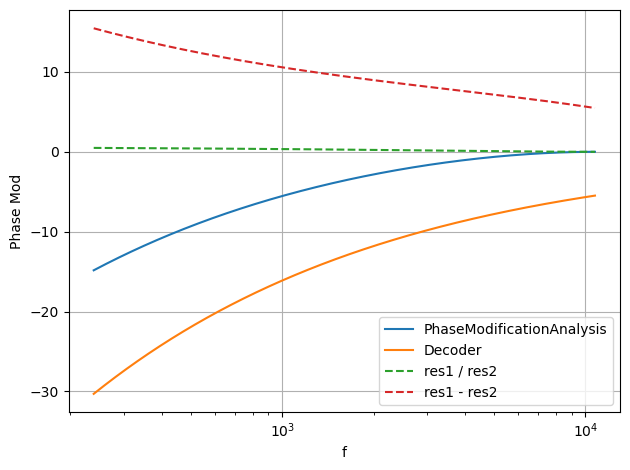

In [ ]:
%load_ext autoreload
%autoreload 2

from waveform_analysis import PhaseModificationAnalysis

z_1 = 0.5
z_2 = 0.3
m_1 = 1.4
m_2 = 2.
fmin = 4e-5
fmax = 1.8e-2

network_file = os.path.abspath(os.path.expanduser('~/projects/npe/npe/utils/param_estimation_test/npe_BNS_3.pt'))
network_kwargs = dict(depth=4, width=512, data_dim=640, grid_dim=2)
#print('network_file: ', network_file)
vae_analyzer = PhaseModificationAnalysis(network_file, network_kwargs, min_fgeom=fmin)


m_tot = m_1 + m_2
freqs1 = 10**np.linspace(np.log10(fmin), np.log10(fmax), 640) / m_tot / MSUN_S

res1 = vae_analyzer.phase_mod(freqs1, m_1, m_2, 0., 0., z_1, z_2)

z_abs = np.sqrt(z_1*z_1 + z_2*z_2)
z = torch.tensor([z_1/z_abs, z_2/z_abs], device=vae_analyzer.device, dtype=torch.float32).view(1, -1)
cond = torch.ones((1,4), dtype=torch.float32)/2
res2 = vae_analyzer.model.decoder(z, cond).detach().numpy().reshape(640,)

freqs2 = 10**vae_analyzer.model_loggeom_freqs / m_tot / MSUN_S

resratio = torch.tensor(res1, dtype=torch.float32) / res2
resdiff = torch.tensor(res1, dtype=torch.float32) - res2

#print(res1)

plt.plot(freqs1, res1, label='PhaseModificationAnalysis')
plt.plot(freqs2, res2, label='Decoder')
plt.plot(freqs1, resratio, label='res1 / res2', linestyle='--')
plt.plot(freqs1, resdiff, label='res1 - res2', linestyle='--')

print(resratio)

plt.xlabel('f')
plt.ylabel('Phase Mod')
#plt.yscale('log')
plt.xscale('log')

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()